# Baseline against the CNN

How much the learned time-frequency representation adds over hand-engineered descriptors, and how
much of either survives the metadata control.

Run these first:

```
python -m src.train.xgb    --config configs/base.yaml
python -m src.train.cnn    --config configs/base.yaml
python -m src.evaluate.report --config configs/base.yaml
```

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config

cfg = load_config("configs/base.yaml")
META = cfg.paths.metadata
REPORT = cfg.paths.reports / cfg.name
pd.set_option("display.width", 160)

## Headline

The control sees native sample rate, recording year, clip duration and file size, and no audio at
all. Its score is the floor. Read the margin column, not the mean.

In [2]:
margins = pd.read_csv(REPORT / "margin_over_control.csv")
margins.round(4)

,model,mean,control,margin,low,high,p_value,agreeing,folds
0,xgboost,0.7567,0.8684,-0.1117,-0.3034,0.0799,0.2471,38,50
1,cnn_small,0.7438,0.8837,-0.1399,-0.6702,0.3904,0.5046,4,5
2,cnn,0.6924,0.8837,-0.1913,-0.6758,0.2933,0.3346,4,5


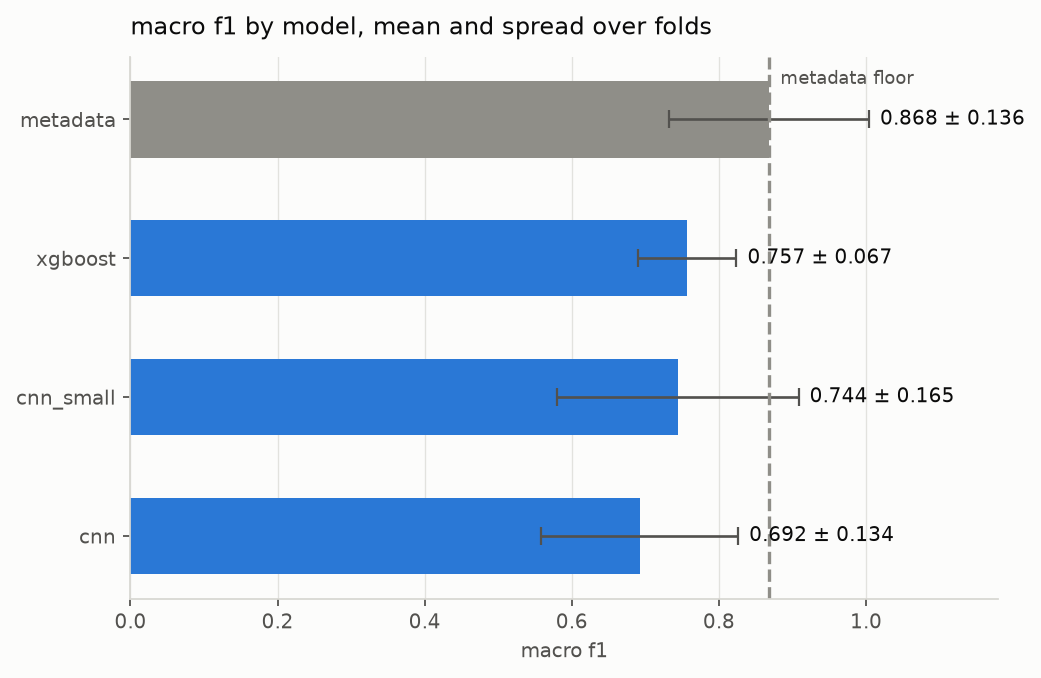

In [3]:
display(Image(filename=str(REPORT / "model_comparison.png")))

## Spread across folds

Humpback whale survives on around a dozen tapes, so a single number would hide most of the
uncertainty. Every fold's score is listed here.

In [4]:
for model in ("xgboost", "cnn", "metadata"):
    path = REPORT / model / "fold_metrics_clip.csv"
    if path.exists():
        folds = pd.read_csv(path)
        print(model)
        columns = ["fold", "accuracy", "macro_f1"]
        columns += [c for c in folds.columns if c.startswith("recall_")]
        display(folds[columns].round(3))

xgboost


,fold,accuracy,macro_f1,recall_HumpbackWhale,recall_SpermWhale,recall_KillerWhale
0,0,0.768,0.725,0.806,0.803,0.749
1,1,0.783,0.679,0.236,0.975,0.975
2,2,0.880,0.691,0.174,0.975,0.937
3,3,0.852,0.806,0.853,0.837,0.858
4,4,0.775,0.726,0.699,0.626,0.846
5,0,0.749,0.711,0.847,0.778,0.724
6,1,0.819,0.763,0.484,0.901,0.952
7,2,0.903,0.731,0.261,0.906,0.987
8,3,0.853,0.812,0.853,0.862,0.850
9,4,0.831,0.774,0.639,0.936,0.821


cnn


,fold,accuracy,macro_f1,recall_HumpbackWhale,recall_SpermWhale,recall_KillerWhale
0,0,0.655,0.614,1.000,0.645,0.611
1,1,0.677,0.499,0.000,1.000,0.882
2,2,0.917,0.763,0.290,0.975,0.977
3,3,0.909,0.831,0.912,0.754,0.969
4,4,0.856,0.756,0.446,0.690,0.987


metadata


,fold,accuracy,macro_f1,recall_HumpbackWhale,recall_SpermWhale,recall_KillerWhale
0,0,0.989,0.981,1.000,0.985,0.989
1,1,1.000,1.000,1.000,1.000,1.000
2,2,0.937,0.851,0.464,0.995,0.977
3,3,0.918,0.657,0.059,1.000,0.998
4,4,0.958,0.929,0.795,0.916,1.000
5,0,0.651,0.732,1.000,1.000,0.467
6,1,0.999,0.999,1.000,1.000,0.998
7,2,0.948,0.861,0.464,1.000,0.992
8,3,0.918,0.657,0.059,1.000,0.998
9,4,0.978,0.947,0.795,0.995,1.000


## Per species recall

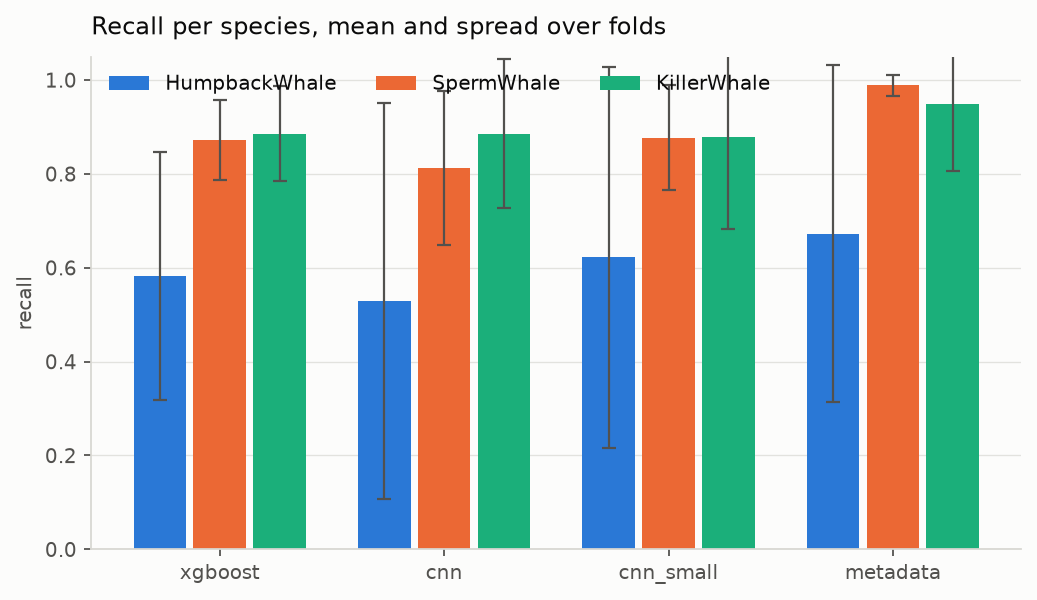

In [5]:
display(Image(filename=str(REPORT / "per_class_recall.png")))

## Confusion, all folds pooled

xgboost


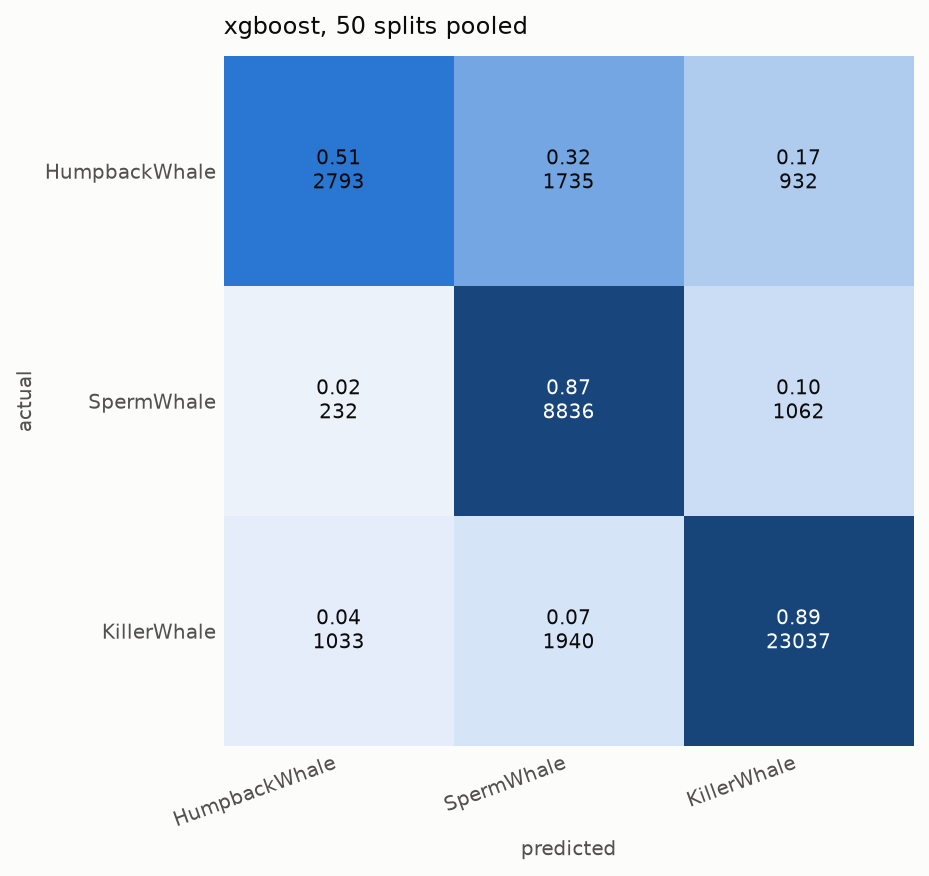

cnn


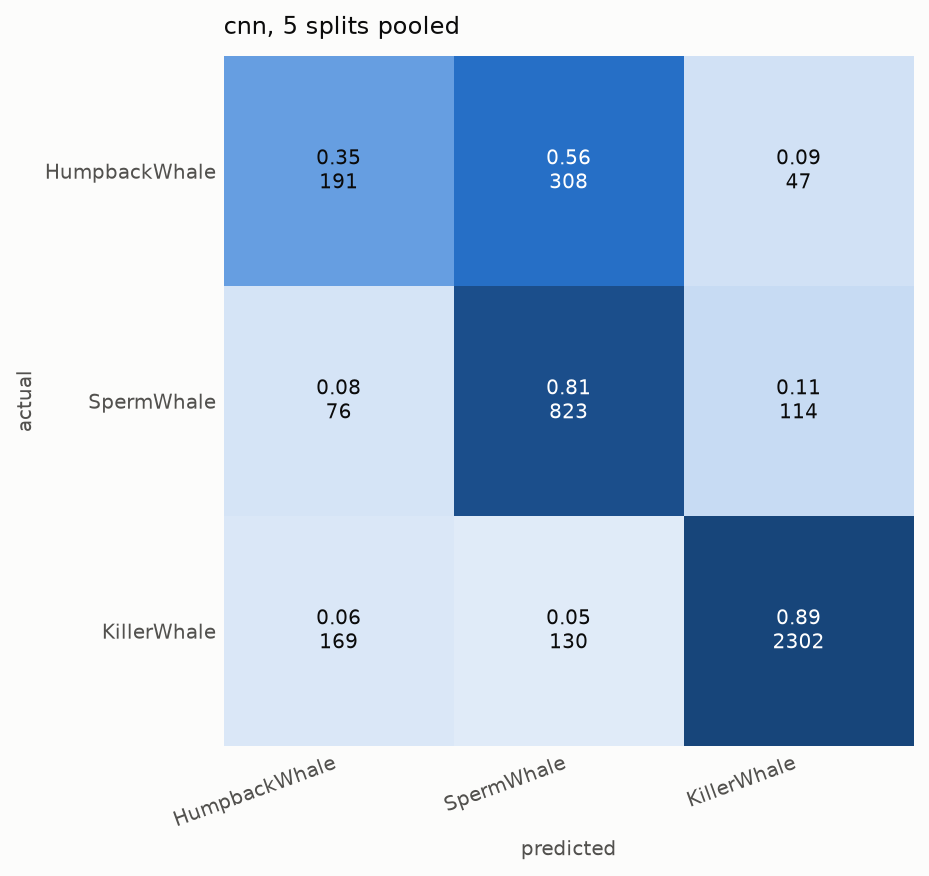

metadata


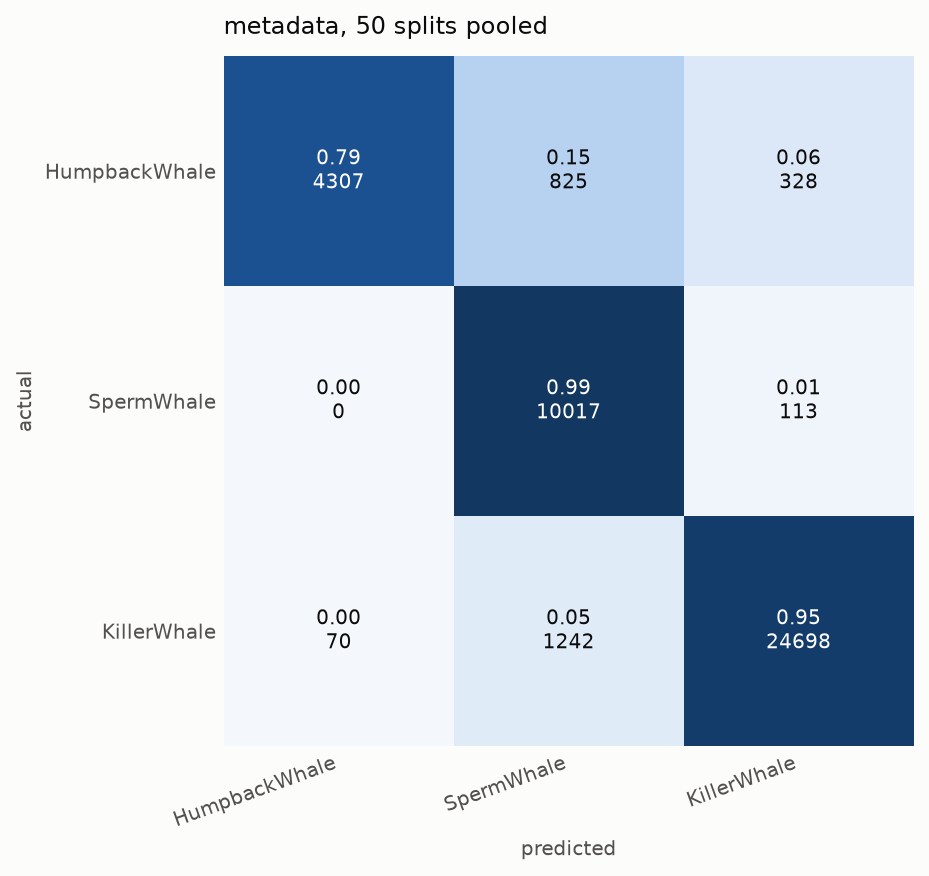

In [6]:
for model in ("xgboost", "cnn", "metadata"):
    path = REPORT / f"confusion_{model}.png"
    if path.exists():
        print(model)
        display(Image(filename=str(path)))

## Training curves

In [7]:
path = REPORT / "training_history.png"
display(Image(filename=str(path))) if path.exists() else print("no CNN history yet")

no CNN history yet
